In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model

In [3]:
def build_encoder():
    # Inputs
    video_input = keras.Input(shape=(32, 128, 128, 3), name="video_input")
    text_input = keras.Input(shape=(512,), name="text_embedding")  # Add text input

    # CNN Feature Extraction for video
    x = layers.TimeDistributed(layers.Conv2D(64, (3, 3), activation="relu"))(video_input)
    x = layers.TimeDistributed(layers.MaxPooling2D((2, 2)))(x)
    x = layers.TimeDistributed(layers.Conv2D(128, (3, 3), activation="relu"))(x)
    x = layers.TimeDistributed(layers.MaxPooling2D((2, 2)))(x)

    # Flatten spatial features
    x = layers.TimeDistributed(layers.Flatten())(x)

    # LSTM over time dimension (frames)
    x = layers.LSTM(512, return_sequences=True)(x)
    x = layers.LSTM(512, return_sequences=False, name="video_lstm_output")(x)

    # Combine with text embedding
    combined = layers.Concatenate()([x, text_input])  # Shape: (B, 1024)

    # Optional: Dense layer to compress to latent dimension
    z = layers.Dense(512, activation="relu", name="encoder_output")(combined)

    # Define Model
    encoder_model = keras.Model(inputs=[video_input, text_input], outputs=z, name="video_encoder")
    return encoder_model


In [4]:
encoder = build_encoder()
encoder.summary()

Model: "video_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ video_input         │ (None, 32, 128,   │          0 │ -                 │
│ (InputLayer)        │ 128, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 32, 126,   │      1,792 │ video_input[0][0] │
│ (TimeDistributed)   │ 126, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 32, 63,    │          0 │ time_distributed… │
│ (TimeDistributed)   │ 63, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 32, 61,    │     73,856 │ time_distributed… │
│ (TimeDistributed)   │ 61, 128)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_3  │ (None, 32, 30,    │          0 │ time_distributed… │
│ (TimeDistributed)   │ 30, 128)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_4  │ (None, 32,        │          0 │ time_distributed… │
│ (TimeDistributed)   │ 115200)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 32, 512)   │ 236,980,2… │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ video_lstm_output   │ (None, 512)       │  2,099,200 │ lstm[0][0]        │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_embedding      │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1024)      │          0 │ video_lstm_outpu… │
│ (Concatenate)       │                   │            │ text_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_output      │ (None, 512)       │    524,800 │ concatenate[0][0] │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 239,679,872 (914.31 MB)

 Trainable params: 239,679,872 (914.31 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
def build_decoder():
    decoder_input = keras.Input(shape=(512,), name="decoder_input")

    # Repeat latent vector across 32 frames
    x = layers.RepeatVector(32)(decoder_input)  # (B, 32, 512)

    # Temporal modeling
    x = layers.LSTM(512, return_sequences=True)(x)

    # Project each time step to 128x128x3 frame
    x = layers.TimeDistributed(layers.Dense(128 * 128 * 3, activation="relu"))(x)
    x = layers.TimeDistributed(layers.Reshape((128, 128, 3)))(x)  # (B, 32, 128, 128, 3)

    decoder_output = x  # video frames

    decoder_model = keras.Model(inputs=decoder_input, outputs=decoder_output, name="video_decoder")
    return decoder_model


In [6]:
decoder = build_decoder()
decoder.summary()

Model: "video_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 32, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32, 512)        │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 32, 49152)      │    25,214,976 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 32, 128, 128,   │             0 │
│ (TimeDistributed)               │ 3)                     │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,314,176 (104.20 MB)

 Trainable params: 27,314,176 (104.20 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
class TimestepEmbedding(layers.Layer):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def call(self, t):
        half_dim = self.dim // 2
        emb = tf.cast(t, tf.float32)[:, None]
        freqs = tf.exp(
            -tf.math.log(10000.0) * tf.range(half_dim, dtype=tf.float32) / half_dim
        )
        emb = emb * freqs
        emb = tf.concat([tf.sin(emb), tf.cos(emb)], axis=1)
        return emb

In [8]:
def diffusion_unet(input_shape=(128, 128, 3), embedding_dim=128, filters=64):
    """
    Diffusion U-Net model using Functional API with sinusoidal timestep embedding.
    
    Args:
        input_shape: Shape of input images (Height, Width, Channels).
        embedding_dim: Dimension of the time embedding.
        filters: Base number of filters for convolution layers.

    Returns:
        A Keras Model for diffusion-based noise estimation.
    """
    # Inputs
    x_input = layers.Input(shape=input_shape, name="image_input")     # (B, H, W, C)
    t_input = layers.Input(shape=(), dtype=tf.int32, name="timestep") # (B,)

    # Timestep embedding
    t_embed = TimestepEmbedding(embedding_dim)(t_input)               # (B, embedding_dim)
    t_embed = layers.Dense(filters, activation="relu")(t_embed)
    t_embed = layers.Dense(filters, activation="relu")(t_embed)
    
    # Project and reshape to (B, 1, 1, C) to match spatial dimensions
    t_proj = layers.Dense(input_shape[-1], activation="linear")(t_embed)  # Match channels
    t_proj = layers.Reshape((1, 1, input_shape[-1]))(t_proj)              # (B, 1, 1, C)

    # Inject timestep into input image
    x = layers.Add()([x_input, t_proj])  # (B, H, W, C)

    # Encoder
    x1 = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    p1 = layers.MaxPooling2D(2)(x1)

    x2 = layers.Conv2D(filters * 2, 3, padding="same", activation="relu")(p1)
    p2 = layers.MaxPooling2D(2)(x2)

    x3 = layers.Conv2D(filters * 4, 3, padding="same", activation="relu")(p2)
    p3 = layers.MaxPooling2D(2)(x3)

    # Bottleneck
    x = layers.Conv2D(filters * 8, 3, padding="same", activation="relu")(p3)

    # Decoder
    x = layers.Conv2DTranspose(filters * 4, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Concatenate()([x3, x])
    x = layers.Conv2D(filters * 4, 3, padding="same", activation="relu")(x)

    x = layers.Conv2DTranspose(filters * 2, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Concatenate()([x2, x])
    x = layers.Conv2D(filters * 2, 3, padding="same", activation="relu")(x)

    x = layers.Conv2DTranspose(filters, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Concatenate()([x1, x])
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)

    # Output layer
    output = layers.Conv2D(3, 3, padding="same", activation="sigmoid")(x)

    return Model(inputs=[x_input, t_input], outputs=output, name="DiffusionUNet")

In [9]:
diffusion_model = diffusion_unet()
diffusion_model.summary()


Model: "DiffusionUNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ timestep            │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ timestep_embedding  │ (None, 128)       │          0 │ timestep[0][0]    │
│ (TimestepEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ timestep_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      4,160 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3)         │        195 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1, 3)   │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ image_input[0][0… │
│                     │ 3)                │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      1,792 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 64, 64,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_3[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 16, 16,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_4[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │  1,179,904 │ conv2d_5[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 32, 32,    │          0 │ conv2d_4[0][0],   │
│ (Concatenate)       │ 512)              │            │ conv2d_transpose… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,179,904 │ concatenate_1[0]… │
│                     │ 256)              │            │                 

 Total params: 4,662,790 (17.79 MB)

 Trainable params: 4,662,790 (17.79 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
class FullVideoGenModel(tf.keras.Model):
    def __init__(self, encoder, decoder, diffusion_model, num_frames=32):
        super(FullVideoGenModel, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.diffusion = diffusion_model
        self.num_frames = num_frames

    def call(self, inputs, training=False):
        video_input, text_embedding, timesteps = inputs

        # Encode video + text to latent
        z = self.encoder([video_input, text_embedding])  # shape: (B, latent_dim)
        
        # Decode latent into video frames
        reconstructed_frames = self.decoder(z)  # shape: (B, 32, H, W, 3)

        # Apply diffusion model on each frame
        diffused_frames = []
        for t in range(self.num_frames):
            frame = reconstructed_frames[:, t, :, :, :]     # (B, H, W, 3)
            timestep = tf.expand_dims(timesteps[:, t], axis=-1)  # shape: (B, 1)  # shape: (B, 1)
            diffused = self.diffusion([frame, timestep])      # call DiffusionUNet
            diffused_frames.append(diffused)                # (B, H, W, 3)

        # Stack frames back into video shape
        final_video = tf.stack(diffused_frames, axis=1)  # (B, 32, H, W, 3)
        return final_video


In [11]:
model = FullVideoGenModel(encoder, decoder, diffusion_model)

In [12]:
model.summary()

Model: "full_video_gen_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ video_encoder (Functional)      │ (None, 512)            │   239,679,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ video_decoder (Functional)      │ (None, 32, 128, 128,   │    27,314,176 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ DiffusionUNet (Functional)      │ (None, 128, 128, 3)    │     4,662,790 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271,656,838 (1.01 GB)

 Trainable params: 271,656,838 (1.01 GB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.load_weights("EncoderDecoder_Diffusion_final.weights.h5")

In [15]:
from transformers import TFCLIPModel, CLIPProcessor

clip_model = TFCLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")


All model checkpoint layers were used when initializing TFCLIPModel.

All the layers of TFCLIPModel were initialized from the model checkpoint at openai/clip-vit-base-patch32.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFCLIPModel for predictions without further training.


In [16]:
def encode_text_clip(texts):
    inputs = clip_processor(text=texts, return_tensors="tf", padding=True, truncation=True)
    text_features = clip_model.get_text_features(**inputs)
    return text_features.numpy()

In [103]:
text = "man"

In [104]:
text_embeddings=encode_text_clip(text)

In [105]:
text_embeddings= np.array(text_embeddings) 

In [106]:
print("Text Embeddings Shape:", text_embeddings.shape)

Text Embeddings Shape: (1, 512)


In [107]:
timesteps = tf.random.uniform((1, 32), minval=0, maxval=1000, dtype=tf.int32)

In [108]:
batch_size = 1

video_input = tf.random.normal((1, 32, 128, 128, 3))   # no need to normalize (normal distribution with mean=0 and std=1) and shape already (32,128,128,3)


In [109]:
predicted_video = model((video_input, text_embeddings, timesteps), training=False)

In [110]:
def show_video_frames(video_tensor, num_frames=5):
    video_tensor = tf.clip_by_value(video_tensor, 0.0, 1.0).numpy()
    video_tensor = (video_tensor * 255).astype(np.uint8)  # Upscale to [0, 255]

    fig, axes = plt.subplots(1, num_frames, figsize=(15, 3))
    for i in range(num_frames):
        frame = video_tensor[0, i]  # Shape: (128, 128, 3)
        axes[i].imshow(frame)
        axes[i].axis('off')
    plt.suptitle("Generated Video Frames")
    plt.show()

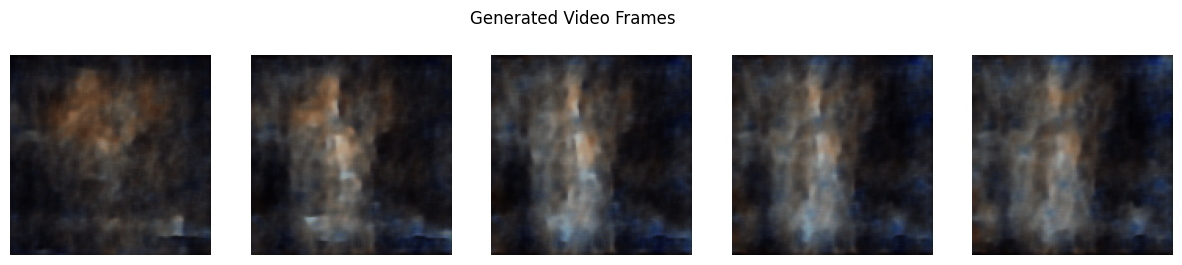

In [111]:
show_video_frames(predicted_video, num_frames=5)

In [83]:
import cv2
import os

def show_and_save_video(video_tensor, num_frames=32, save_path="generated_video.mp4", fps=6):
    # Ensure pixel values are valid for video
    video_tensor = tf.clip_by_value(video_tensor, 0.0, 1.0).numpy()
    video_tensor = (video_tensor * 255).astype(np.uint8)  # Shape: (1, 32, 128, 128, 3)

    # Get frame dimensions
    height, width = video_tensor.shape[2], video_tensor.shape[3]
    
    # Define the codec and create VideoWriter object
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # or 'XVID'
    out = cv2.VideoWriter(save_path, fourcc, fps, (width, height))

    print(f"Saving video to {save_path}...")

    for i in range(min(num_frames, video_tensor.shape[1])):
        frame = video_tensor[0, i]
        frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)  # Convert to BGR for OpenCV
        out.write(frame_bgr)

    out.release()
    print("✅ Video saved successfully.")



In [84]:
show_and_save_video(predicted_video, num_frames=32, save_path="generated_video.mp4", fps=6)


Saving video to generated_video.mp4...
✅ Video saved successfully.
